# Evaluación de clasificadores . Derecho a las Víctimas

## ¿Qué hace este notebook?

Compara las predicciones de cualquier clasificador contra las etiquetas reales del test set y muestra:

- Métricas principales (Accuracy, F1, Precision, Recall, Kappa)
- Matriz de confusión
- Análisis de errores 

**Para evaluar un clasificador nuevo:** se cambian las rutas en la Sección 1 y se corren todas las celdas 


### Nota sobre las métricas

La métrica principal es **F1 macro**, no Accuracy, porque las clases están desbalanceadas (más negativos que positivos). Además para Kappa el criterio es el siguiente:

| Kappa     | Interpretación   |
| < 0.0     | Peor que el azar |
| 0.0 – 0.2 | Leve             |
| 0.2 – 0.4 | Débil            |
| 0.4 – 0.6 | Moderado         |
| 0.6 – 0.8 | Bueno            | 
| > 0.8     | Excelente        |

> **Observación:** los falsos negativos (predijo NO, era SÍ) son más costosos que los falsos positivos en este dominio, porque perder una norma de derechos de víctimas es peor que incluir una de más.

## 1. Configuración

**Solo modificar esta sección para evaluar un clasificador nuevo.**

In [ ]:
#  Archivo con las predicciones del clasificador a evaluar 
# Debe tener columnas: 'Número' y 'caso_ok' (la predicción)
# Opcionalmente: 'Justificación' para el análisis de errores
FILE_PREDICCIONES  = 'resultado_gemini_API.xlsx'

# Nombre del clasificador (aparece en los gráficos y tablas)
NOMBRE_CLASIFICADOR = 'Gemini'

# Archivo original con las etiquetas reales
FILE_ORIGINAL = 'Normativa_nacional_víctimas_1869-2023.xlsx'

#Archivo test con las etiquetas originales 
FILE_TEST_ETIQUETAS =  'test_con_etiqueta.xlsx'

# Parámetros del split
TEST_SIZE    = 0.30
RANDOM_STATE = 42

## 2. Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, cohen_kappa_score
)
from sklearn.model_selection import train_test_split
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


## 3. Carga y merge de datos

In [9]:
df_pred = pd.read_excel(FILE_PREDICCIONES)
df_test = pd.read_excel(FILE_TEST_ETIQUETAS)
df_pred['Número'] = df_pred['Número'].astype(str).str.strip()
df_test['Número'] = df_test['Número'].astype(str).str.strip()

merged = df_pred.merge(
    df_test[['Número', 'caso_ok']],
    on='Número',
    suffixes=('_pred', '_real')
)
merged = merged[merged['caso_ok_pred'] != -1]
n = len(merged)

y_pred = merged['caso_ok_pred']
y_real = merged['caso_ok_real']

## 4. Métricas

In [10]:
# Tabla de métricas
metricas = {
    'Accuracy':              round(accuracy_score(y_real, y_pred), 3),
    'F1 macro':            round(f1_score(y_real, y_pred, average='macro'), 3),
    'F1 positivos (SÍ)':     round(f1_score(y_real, y_pred, pos_label=1), 3),
    'F1 negativos (NO)':     round(f1_score(y_real, y_pred, pos_label=0), 3),
    'Precision positivos':   round(precision_score(y_real, y_pred, pos_label=1), 3),
    'Recall positivos':      round(recall_score(y_real, y_pred, pos_label=1), 3),
    'Kappa':                 round(cohen_kappa_score(y_real, y_pred), 3),
}

df_metricas = pd.DataFrame(
    metricas.items(), columns=['Métrica', 'Valor']
).set_index('Métrica')

print(f'Clasificador: {NOMBRE_CLASIFICADOR}')
print()
display(
    df_metricas.style
    .format('{:.3f}')
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=0)
    .set_caption(f'Métricas — {NOMBRE_CLASIFICADOR}')
)

Clasificador: Gemini



,Valor
Métrica,
Accuracy,0.444
F1 macro,0.441
F1 positivos (SÍ),0.483
F1 negativos (NO),0.400
Precision positivos,0.341
Recall positivos,0.824
Kappa,0.068


In [11]:
# ── Reporte detallado por clase ───────────────────────────────────────────────
print(classification_report(
    y_real, y_pred,
    labels=[0, 1],
    target_names=['NO víctima (0)', 'SÍ víctima (1)'],
    zero_division=0
))

                precision    recall  f1-score   support

NO víctima (0)       0.77      0.27      0.40        37
SÍ víctima (1)       0.34      0.82      0.48        17

      accuracy                           0.44        54
     macro avg       0.56      0.55      0.44        54
  weighted avg       0.63      0.44      0.43        54



## 5. Matriz de confusión

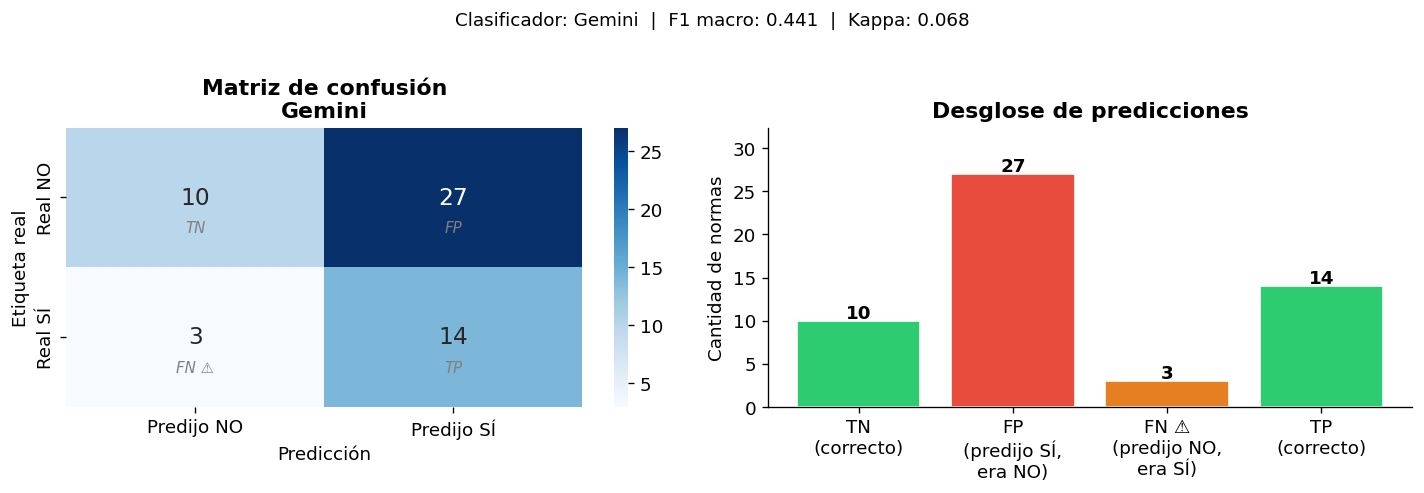

TN=10  FP=27  FN=3  TP=14
Total correctos: 24/54 (44.4%)
Total errores:   30/54 (55.6%)


In [12]:
cm = confusion_matrix(y_real, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Predijo NO', 'Predijo SÍ'],
    yticklabels=['Real NO', 'Real SÍ'],
    annot_kws={'size': 14}
)
ax.set_title(f'Matriz de confusión\n{NOMBRE_CLASIFICADOR}', fontweight='bold')
ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Predicción')
for (i, j), label in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN ⚠'), ((1,1),'TP')]:
    ax.text(j+0.5, i+0.75, label, ha='center', fontsize=9, color='gray', style='italic')


ax2 = axes[1]
categorias = ['TN\n(correcto)', 'FP\n(predijo SÍ,\nera NO)', 'FN ⚠\n(predijo NO,\nera SÍ)', 'TP\n(correcto)']
valores    = [tn, fp, fn, tp]
colores    = ['#2ecc71', '#e74c3c', '#e67e22', '#2ecc71']
bars = ax2.bar(categorias, valores, color=colores, edgecolor='white')
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold')
ax2.set_title('Desglose de predicciones', fontweight='bold')
ax2.set_ylabel('Cantidad de normas')
ax2.set_ylim(0, max(valores) * 1.2)

n = len(merged)
plt.suptitle(f'Clasificador: {NOMBRE_CLASIFICADOR}  |  F1 macro: {metricas["F1 macro"]:.3f}  |  Kappa: {metricas["Kappa"]:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Total correctos: {tn+tp}/{n} ({(tn+tp)/n:.1%})')
print(f'Total errores:   {fp+fn}/{n} ({(fp+fn)/n:.1%})')

## 6. Análisis de errores

Se muestran primero los **falsos negativos** (predijo NO, era SÍ) porque son más costosos.

In [13]:
errores = merged[merged['caso_ok_pred'] != merged['caso_ok_real']].copy()
errores['tipo_error'] = errores.apply(
    lambda r: 'FN — predijo NO, era SÍ' if r['caso_ok_pred'] == 0
              else 'FP — predijo SÍ, era NO',
    axis=1
)

print(f'Total errores: {len(errores)} de {n} ({len(errores)/n:.1%})')
print(errores['tipo_error'].value_counts().to_string())

Total errores: 30 de 54 (55.6%)
tipo_error
FP — predijo SÍ, era NO    27
FN — predijo NO, era SÍ     3


In [14]:
# ── Falsos negativos ──────────────────────────────────────────────────────────
fn_df = errores[errores['tipo_error'] == 'FN — predijo NO, era SÍ']

print(f'⚠️  Falsos negativos: {len(fn_df)} casos')
print('(El clasificador dijo NO pero la etiqueta real era SÍ)')
print()

cols = ['Número', 'Título'] if 'Título' in fn_df.columns else ['Número']
if 'Justificación' in fn_df.columns:
    cols.append('Justificación')

pd.set_option('display.max_colwidth', 80)
display(fn_df[cols].reset_index(drop=True))

⚠️  Falsos negativos: 3 casos
(El clasificador dijo NO pero la etiqueta real era SÍ)



,Número,Título,Justificación
0,23280,GUERRA DE MALVINAS,"0: La norma dispone la erección de un monumento, lo cual es un acto conmemor..."
1,888,DUELO NACIONAL,"0: La norma declara un día de duelo nacional en homenaje a las víctimas, lo ..."
2,840,DUELO NACIONAL,"0: La norma es una declaración conmemorativa que no establece derechos, asis..."


In [15]:
# ── Falsos positivos ──────────────────────────────────────────────────────────
fp_df = errores[errores['tipo_error'] == 'FP — predijo SÍ, era NO']

print(f'Falsos positivos: {len(fp_df)} casos')
print('(El clasificador dijo SÍ pero la etiqueta real era NO)')
print()

cols = ['Número', 'Título'] if 'Título' in fp_df.columns else ['Número']
if 'Justificación' in fp_df.columns:
    cols.append('Justificación')

display(fp_df[cols].reset_index(drop=True))

Falsos positivos: 27 casos
(El clasificador dijo SÍ pero la etiqueta real era NO)



,Número,Título,Justificación
0,26004,ACUERDOS,1: La norma aprueba un acuerdo internacional que establece la asistencia ent...
1,25815,CODIGO PENAL. Modificación del mismo. Sustitúyese el artículo 1027 de la Ley...,1: La norma establece un mecanismo de decomiso de bienes vinculados directam...
2,25632,CONVENCIONES,1: La norma aprueba una convención que establece la indemnización de las víc...
3,844,FONDO DE ASISTENCIA DIRECTA A VICTIMAS DE TRATA,1: La norma reglamenta un fondo fiduciario público destinado a la asistencia...
4,21507,FUERZAS ARMADAS Y DE SEGURIDAD,1: La norma establece un subsidio extraordinario como forma de reparación ec...
5,606,JEFATURA DE GABINETE DE MINISTROS,1: La norma crea un programa cuyo objetivo explícito es garantizar la conten...
6,235,PROTECCION CONTRA LA VIOLENCIA FAMILIAR,1: La norma establece centros de información y asesoramiento para víctimas d...
7,26378,CONVENCIONES,1: La norma establece el derecho de las personas con discapacidad víctimas d...
8,27149,MINISTERIO PÚBLICO DE LA DEFENSA DE LA NACIÓN,1: La norma define programas y comisiones dentro de la Defensoría General de...
9,174,ADMINISTRACION PUBLICA NACIONAL,1: La norma define objetivos para dependencias gubernamentales que intervien...


## 7. Comparación entre clasificadores (opcional)

Correr esta celda después de evaluar múltiples clasificadores para comparar sus métricas.

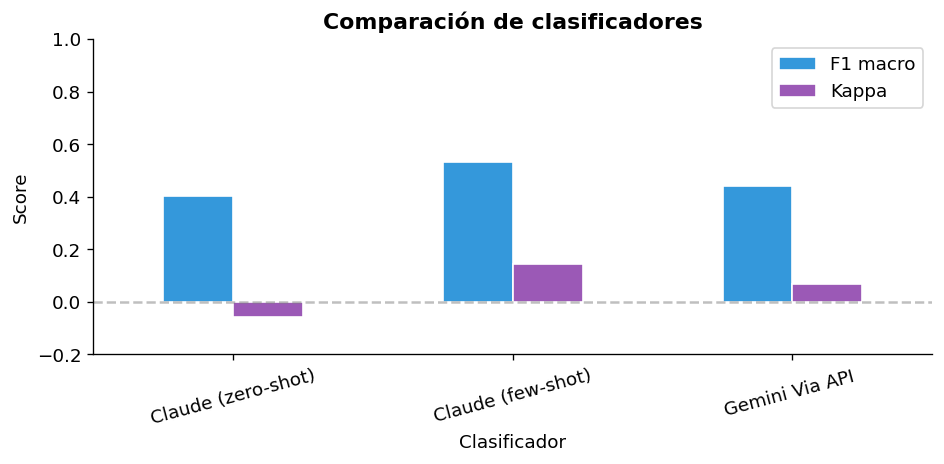

,F1 macro,Kappa
Clasificador,,
Claude (zero-shot),0.402,-0.057
Claude (few-shot),0.531,0.143
Gemini Via API,0.441,0.068


In [16]:
# Completar con los resultados de cada clasificador evaluado
# Copiar los valores de F1 macro y Kappa de cada ejecución anterior

resultados = [
    {'Clasificador': 'Claude (zero-shot)', 'F1 macro': 0.402, 'Kappa': -0.057},
    {'Clasificador': 'Claude (few-shot)', 'F1 macro':0.531 , 'Kappa': 0.143},
    {'Clasificador': 'Gemini Via API ',     'F1 macro': 0.441, 'Kappa': 0.068},
    # {'Clasificador': 'Gemini Colab',    'F1 macro': 0.000, 'Kappa': 0.000},
]

if not resultados:
    print('Todavía no hay resultados para comparar. Completar la lista de arriba.')
else:
    df_comp = pd.DataFrame(resultados).set_index('Clasificador')

    ax = df_comp.plot(
        kind='bar', figsize=(8, 4),
        color=['#3498db', '#9b59b6'],
        edgecolor='white'
    )
    ax.set_title('Comparación de clasificadores', fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.2, 1)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
    plt.tight_layout()
    plt.show()

    display(df_comp)